In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [76]:
df=pd.read_csv("store.csv")

In [108]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_loss
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,1
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,1
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,1
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,0
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,1


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [79]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [80]:
df.isna().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

generating our tareget column : profit_loss

In [81]:
df=df[df['profit']!=0]

In [82]:
df['profit_loss'] = df['profit'].apply(lambda x : 1 if x>0 else 0)

In [83]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_loss
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,1
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,1
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,1
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,0
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,1


In [84]:
df['profit_loss'].value_counts()

profit_loss
1    38079
0    12543
Name: count, dtype: int64

In [85]:
df['sales']=pd.to_numeric(df['sales'],errors='coerce')

In [86]:
df['sales'].dtype

dtype('float64')

In [87]:
df['order_date']=pd.to_datetime(df['order_date'],errors="coerce")
df['ship_date']=pd.to_datetime(df['ship_date'],errors="coerce")

In [88]:
df['order_date'].dtype

dtype('<M8[ns]')

In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
numeric=['sales','quantity','discount','profit','shipping_cost']

In [91]:
for i in numeric:
    print(f"mean of {i} :", df[i].mean())
    print(f"median of {i} :", df[i].median())
    print(f"min of {i} :", df[i].min())
    print(f"max of {i} :", df[i].max())
    print()

mean of sales : 160.8989837990921
median of sales : 76.0
min of sales : 0.0
max of sales : 999.0

mean of quantity : 3.4767689937181463
median of quantity : 3.0
min of quantity : 1
max of quantity : 14

mean of discount : 0.14429572122792464
median of discount : 0.0
min of discount : 0.0
max of discount : 0.85

mean of profit : 29.019691463790444
median of profit : 9.57
min of profit : -6599.978
max of profit : 8399.976

mean of shipping_cost : 26.397330212160718
median of shipping_cost : 7.77
min of shipping_cost : 0.0
max of shipping_cost : 933.57



In [92]:
for i in df:
    print(f"no. of unique values for {i} :" ,df[i].nunique())

no. of unique values for order_id : 24879
no. of unique values for order_date : 564
no. of unique values for ship_date : 580
no. of unique values for ship_mode : 4
no. of unique values for customer_name : 795
no. of unique values for segment : 3
no. of unique values for state : 1094
no. of unique values for country : 147
no. of unique values for market : 7
no. of unique values for region : 13
no. of unique values for product_id : 10254
no. of unique values for category : 3
no. of unique values for sub_category : 17
no. of unique values for product_name : 3786
no. of unique values for sales : 993
no. of unique values for quantity : 14
no. of unique values for discount : 27
no. of unique values for profit : 24574
no. of unique values for shipping_cost : 9981
no. of unique values for order_priority : 4
no. of unique values for year : 4
no. of unique values for profit_loss : 2


the graph of total no. of losses and profit

([<matplotlib.axis.XTick at 0x20e672b0910>,
 [Text(0, 0, 'loss'), Text(1, 0, 'profit')])

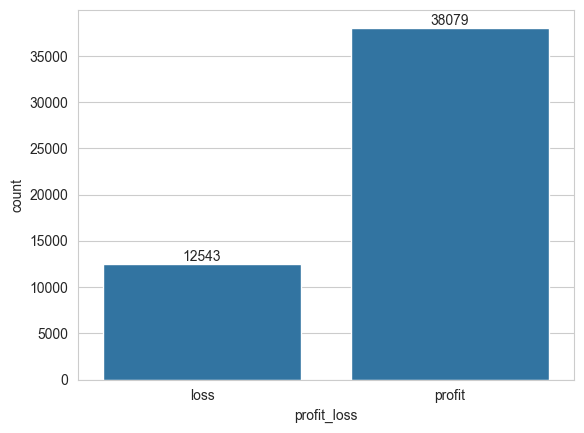

In [93]:
sns.set_style("whitegrid")
k=sns.countplot(x="profit_loss",data=df)
for container in k.containers:
    k.bar_label(container)
plt.xticks([0,1],["loss","profit"])

([<matplotlib.axis.XTick at 0x20e6ebb1810>,
 [Text(0, 0, 'loss'), Text(1, 0, 'profit')])

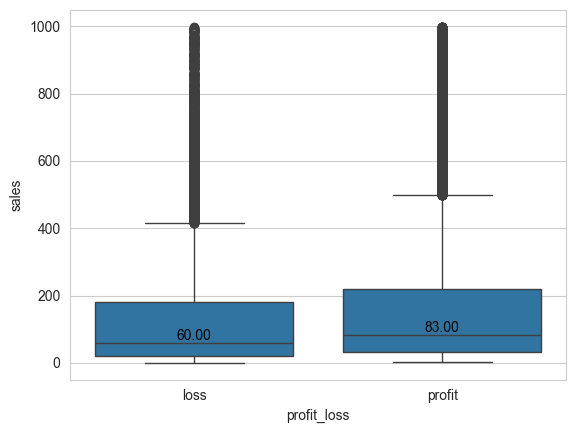

In [105]:
k=sns.boxplot(x="profit_loss",y="sales",data=df)
medians = df.groupby('profit_loss')['sales'].median()
for i, median in enumerate(medians):
    k.text(i, median, f'{median:.2f}', 
            ha='center', va='bottom', color='black')
plt.xticks([0,1],["loss","profit"])


([<matplotlib.axis.XTick at 0x20e6f3b0050>,
 [Text(0, 0, 'loss'), Text(1, 0, 'profit')])

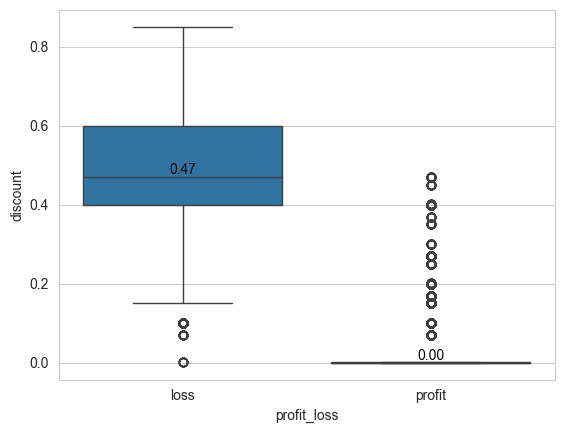

In [113]:
k=sns.boxplot(x="profit_loss",y="discount",data=df)
medians = df.groupby('profit_loss')['discount'].median()
for i, median in enumerate(medians):
    k.text(i, median, f'{median:.2f}', 
            ha='center', va='bottom', color='black')
plt.xticks([0,1],["loss","profit"])

([<matplotlib.axis.XTick at 0x20e70de4b90>,
 [Text(0, 0, 'loss'), Text(1, 0, 'profit')])

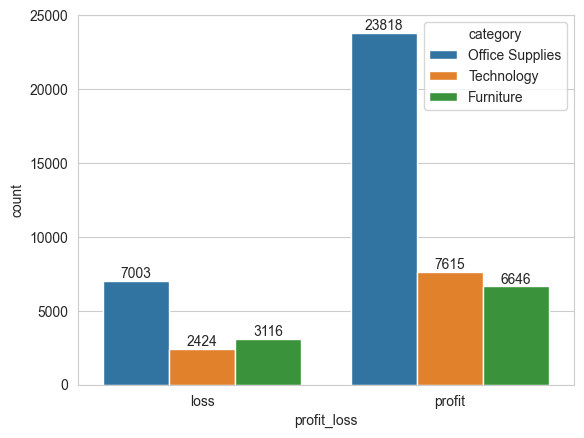

In [117]:
k=sns.countplot(x="profit_loss",hue="category",data=df)
for i in k.containers:
    k.bar_label(i)
plt.xticks([0,1],["loss","profit"])

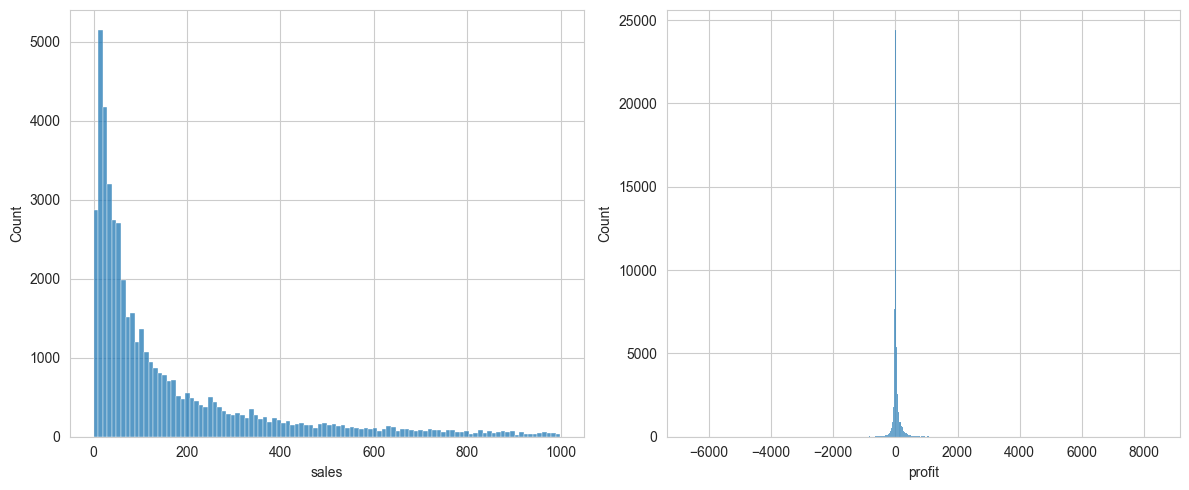

In [125]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(x="sales",data=df,ax=axes[0])
sns.histplot(x="profit",data=df,ax=axes[1])
plt.tight_layout()